In [48]:
import os
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam, RMSprop
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image
import seaborn as sns
import matplotlib.pyplot as plt

In [5]:
path = 'C:/Users/rodrigo/Desktop/Machine Learning Aplicada/Nova_atividade/dc_small/'

In [6]:
def cria_dataframe(caminho):
    arquivos = []
    rotulos = []
    for arquivo in os.listdir(caminho):
        if arquivo.startswith('cat'):
            rotulos.append('cat')
        elif arquivo.startswith('dog'):
            rotulos.append('dog')
        arquivos.append(arquivo)
    return pd.DataFrame({'arquivo': arquivos, 'rotulo': rotulos})

In [7]:
df_dados = cria_dataframe(os.path.join(path, 'train'))
train_df, validation_df = train_test_split(df_dados, test_size=0.3, stratify=df_dados['rotulo'], random_state=0)

In [11]:
# Criando o dataframe de teste
test_df = cria_dataframe(os.path.join(path, 'test'))

In [12]:
# Data Augmentation
train_datagen = ImageDataGenerator(
    preprocessing_function=tf.keras.applications.efficientnet.preprocess_input,
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True
)
validation_datagen = ImageDataGenerator(preprocessing_function=tf.keras.applications.efficientnet.preprocess_input)
test_datagen = ImageDataGenerator(preprocessing_function=tf.keras.applications.efficientnet.preprocess_input)

In [13]:
# Função para criar geradores de dados
def create_generator(datagen, dataframe, directory):
    return datagen.flow_from_dataframe(
        dataframe,
        directory=directory,
        x_col='arquivo',
        y_col='rotulo',
        target_size=(224, 224),
        batch_size=32,
        class_mode='categorical'
    )

In [14]:
# Criando os geradores de dados
train_generator = create_generator(train_datagen, train_df, os.path.join(path, 'train'))
validation_generator = create_generator(validation_datagen, validation_df, os.path.join(path, 'train'))
test_generator = create_generator(test_datagen, test_df, os.path.join(path, 'test'))

Found 1400 validated image filenames belonging to 2 classes.
Found 600 validated image filenames belonging to 2 classes.
Found 1000 validated image filenames belonging to 2 classes.


In [15]:
# Carregando o modelo EfficientNetB0 pré-treinado
efficientnet_base = EfficientNetB0(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

16705208/16705208 [==============================] - 5s 0us/step


In [16]:
# Congelando as camadas do modelo base
for layer in efficientnet_base.layers:
    layer.trainable = False

In [17]:
# Criando o modelo completo com camadas adicionais
efficientnet_model = tf.keras.Sequential([
    efficientnet_base,
    GlobalAveragePooling2D(),
    Dense(1024, activation='relu'),
    Dense(2, activation='softmax')  # 2 classes: cat e dog
])

In [18]:
# Variação de otimizadores
otimizadores = {
    'Adam': Adam(learning_rate=0.0001),
    'RMSprop': RMSprop(learning_rate=0.0005)
}

In [19]:
# Compilando o modelo com o otimizador Adam
efficientnet_model.compile(optimizer=otimizadores['Adam'], loss='categorical_crossentropy', metrics=['accuracy'])

In [20]:
# Treinando o modelo
efficientnet_model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // train_generator.batch_size,
    validation_data=validation_generator,
    validation_steps=validation_generator.samples // validation_generator.batch_size,
    epochs=25
)

Epoch 1/25
43/43 [==============================] - 43s 893ms/step - loss: 0.1994 - accuracy: 0.9401 - val_loss: 0.0515 - val_accuracy: 0.9948
Epoch 2/25
43/43 [==============================] - 37s 859ms/step - loss: 0.0548 - accuracy: 0.9861 - val_loss: 0.0318 - val_accuracy: 0.9965
Epoch 3/25
43/43 [==============================] - 38s 876ms/step - loss: 0.0393 - accuracy: 0.9898 - val_loss: 0.0245 - val_accuracy: 0.9948
Epoch 4/25
43/43 [==============================] - 38s 872ms/step - loss: 0.0388 - accuracy: 0.9890 - val_loss: 0.0218 - val_accuracy: 0.9948
Epoch 5/25
43/43 [==============================] - 56s 1s/step - loss: 0.0290 - accuracy: 0.9912 - val_loss: 0.0197 - val_accuracy: 0.9965
Epoch 6/25
43/43 [==============================] - 51s 1s/step - loss: 0.0250 - accuracy: 0.9935 - val_loss: 0.0185 - val_accuracy: 0.9931
Epoch 7/25
43/43 [==============================] - 49s 1s/step - loss: 0.0275 - accuracy: 0.9905 - val_loss: 0.0232 - val_accuracy: 0.9896
Epoch 8/

In [21]:
# Avaliação nos conjuntos de teste
eval_result_efficientnet = efficientnet_model.evaluate(test_generator)

32/32 [==============================] - 22s 696ms/step - loss: 0.0200 - accuracy: 0.9910


In [22]:
# Gerando predições
predicoes_efficientnet = efficientnet_model.predict(test_generator, steps=test_generator.samples // test_generator.batch_size)

31/31 [==============================] - 19s 580ms/step


In [23]:
# Convertendo as predições para as classes
y_pred_efficientnet = np.argmax(predicoes_efficientnet, axis=1)

In [24]:
# Verdadeiras classes
y_true = test_generator.classes

In [28]:
# Ajustar y_true para corresponder ao tamanho de y_pred_efficientnet
y_true = y_true[:len(y_pred_efficientnet)]

In [29]:
# Matriz de Confusão
conf_matrix_efficientnet = confusion_matrix(y_true, y_pred_efficientnet)

In [30]:
# Relatório de Classificação
report_efficientnet = classification_report(y_true, y_pred_efficientnet, target_names=test_generator.class_indices.keys())


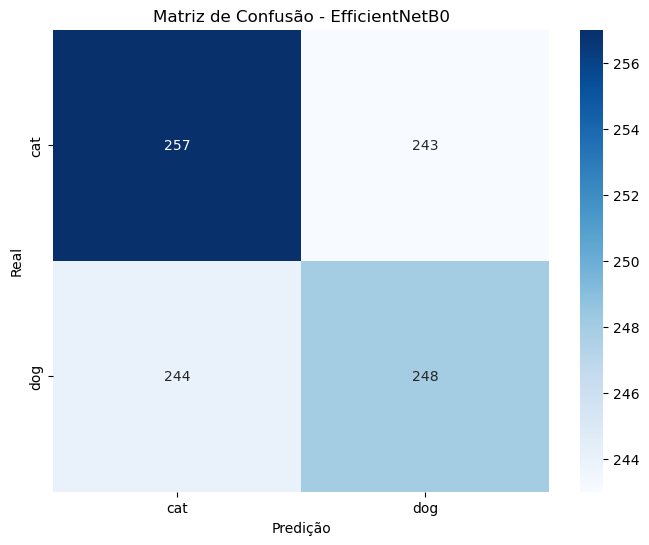

In [31]:
# Visualizando a Matriz de Confusão
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_efficientnet, annot=True, fmt='d', cmap='Blues', xticklabels=test_generator.class_indices.keys(), yticklabels=test_generator.class_indices.keys())
plt.title('Matriz de Confusão - EfficientNetB0')
plt.xlabel('Predição')
plt.ylabel('Real')
plt.show()

In [32]:
# Imprimir o relatório de classificação
print("Relatório de Classificação - EfficientNetB0:")
print(report_efficientnet)

Relatório de Classificação - EfficientNetB0:
              precision    recall  f1-score   support

         cat       0.51      0.51      0.51       500
         dog       0.51      0.50      0.50       492

    accuracy                           0.51       992
   macro avg       0.51      0.51      0.51       992
weighted avg       0.51      0.51      0.51       992



In [41]:
def apply_pca_to_images(generator, n_components=32):
    # Obtenção das imagens e rótulos do gerador
    images, labels = next(generator)
    
    # Redimensionar as imagens para vetores 1D
    images_reshaped = images.reshape(images.shape[0], -1)
    
    # Normalizando as imagens
    scaler = StandardScaler()
    images_scaled = scaler.fit_transform(images_reshaped)
    
    # Verificando a quantidade de amostras e características
    n_samples, n_features = images_scaled.shape
    print(f"Amostras: {n_samples}, Características: {n_features}")
    
    # Aplicando PCA
    pca = PCA(n_components=min(n_components, n_features))  # Garantir que n_components não seja maior que as características
    images_pca = pca.fit_transform(images_scaled)
    
    return images_pca, labels

In [42]:
# Aplicando PCA nas imagens de treino, validação e teste
train_images_pca, train_labels_pca = apply_pca_to_images(train_generator)
validation_images_pca, validation_labels_pca = apply_pca_to_images(validation_generator)
test_images_pca, test_labels_pca = apply_pca_to_images(test_generator)

print("PCA aplicado nas imagens.")

Amostras: 32, Características: 150528
Amostras: 32, Características: 150528
Amostras: 32, Características: 150528
PCA aplicado nas imagens.


In [49]:
# Função para predição de uma imagem individual
def predicao_img(amostra, modelo):
    # Carregar a imagem
    img = image.load_img(amostra, target_size=(224, 224))  # Ajuste o tamanho conforme necessário
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)  # Aumenta a dimensão para (1, 224, 224, 3)

    # Normalização da imagem (se necessário, conforme o treinamento do modelo)
    img_array = img_array / 255.0  # Normalização para valores entre 0 e 1, ajuste conforme seu modelo

    # Fazer a predição
    predicao = modelo.predict(img_array)
    
    # Obter a classe predita (assumindo que você tem um modelo de classificação)
    classe_predita = np.argmax(predicao, axis=1)
    
    # Converter a imagem para a forma de visualização
    img_resposta = img_array[0] * 255.0  # Converter de volta para valores de imagem visíveis
    img_resposta = np.clip(img_resposta, 0, 255).astype('uint8')  # Garantir que os valores estão no intervalo válido
    
    # Retornar a classe predita e a imagem de resposta
    return classe_predita[0], img_resposta


1/1 [==============================] - 1s 1s/step


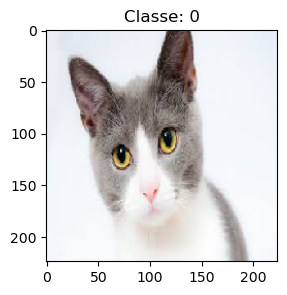

In [51]:
# Caminho da imagem para predição
amostra = path + 'img9.jpeg'  # Atualize com o caminho correto para a sua imagem

# Fazer a predição
classe_predita, img_resposta = predicao_img(amostra, efficientnet_model)

# Exibir a imagem com o título da classe predita
plt.figure(figsize=(3, 3))
plt.imshow(img_resposta)
plt.title(f'Classe: {classe_predita}')
plt.show()